# Missed Trash Pickups Analysis

## Goal
Determine the total amount of damages due to missed trash pickups.

### Fine rule
- First missed pickup at an address = no fine
- Every additional missed pickup at the same address = $200

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("trash_hauler_report.csv")
df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066


In [4]:
df.shape

(20226, 11)

In [5]:
df.columns

Index(['Request Number', 'Date Opened', 'Request ', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20226 entries, 0 to 20225
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Request Number    20226 non-null  int64  
 1   Date Opened       20226 non-null  object 
 2   Request           20226 non-null  object 
 3   Description       20195 non-null  object 
 4   Incident Address  20217 non-null  object 
 5   Zip Code          20151 non-null  float64
 6   Trash Hauler      19325 non-null  object 
 7   Trash Route       19279 non-null  object 
 8   Council District  20177 non-null  float64
 9   State Plan X      20198 non-null  float64
 10  State Plan Y      20198 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.7+ MB


In [7]:
df['Request '].value_counts()

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [10]:
df['Date Opened'] = pd.to_datetime(df['Date Opened'], errors='coerce')

In [11]:
df['Trash Hauler Clean'] = df['Trash Hauler'].str.upper().str.strip()

In [12]:
missed = df[df['Request '] == 'Trash - Curbside/Alley Missed Pickup'].copy()
missed.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Trash Hauler Clean
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565,RED RIVER
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571,RED RIVER
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923,WASTE IND
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066,RED RIVER
8,25330,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed.,4484 Lavergne Couchville Pike,37013.0,RED RIVER,4210,33.0,1.794534e+06,618749.342732,RED RIVER


In [13]:
missed.shape

(15028, 12)

In [16]:
address_counts['fines'] = (address_counts['missed_count'] - 1).clip(lower=0) * 200
address_counts.head()

,Incident Address,missed_count,fines
0,1 BELLE FORREST AVE C,1,0
1,10 Belle Forrest Ave,1,0
2,"100 Bluefield Square, Nashville, TN 37214, Uni...",1,0
3,100 Braxton Hill Ct,1,0
4,100 Brook Hollow Rd,1,0


In [17]:
total_fines = address_counts['fines'].sum()
total_fines

np.int64(720800)

## Answer to Main Question

**Total damages due to missed pickups: $720,800**

In [18]:
complaint_types = df['Request '].value_counts()
complaint_types

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

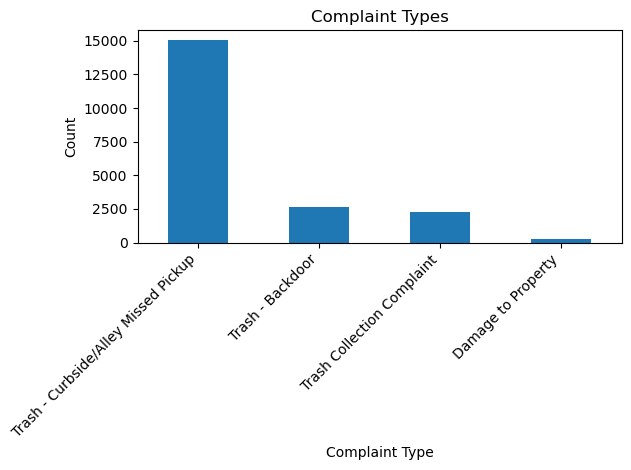

In [19]:
complaint_types.plot(kind='bar')
plt.title('Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Other Complaint Types

The dataset includes four request categories:
- Trash - Curbside/Alley Missed Pickup
- Trash - Backdoor
- Trash Collection Complaint
- Damage to Property

In [20]:
missed = missed.sort_values(['Incident Address', 'Date Opened', 'Request Number']).copy()
missed['miss_num_at_address'] = missed.groupby('Incident Address').cumcount() + 1
missed['fine_current'] = missed['miss_num_at_address'].apply(lambda x: 200 if x > 1 else 0)
missed.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Trash Hauler Clean,miss_num_at_address,fine_current
4477,79395,2018-06-29,Trash - Curbside/Alley Missed Pickup,the entire street was missed,1 BELLE FORREST AVE C,37206.0,METRO,9502,7.0,1.751942e+06,677895.310490,METRO,1.0,0
4511,79884,2018-07-02,Trash - Curbside/Alley Missed Pickup,Missed entire street- carts are curbside in fr...,10 Belle Forrest Ave,37206.0,METRO,9502,7.0,1.751718e+06,678077.934103,METRO,1.0,0
10929,155122,2019-03-15,Trash - Curbside/Alley Missed Pickup,MISS,"100 Bluefield Square, Nashville, TN 37214, Uni...",37214.0,RED RIVER,1505,15.0,1.770431e+06,666861.601362,RED RIVER,1.0,0
2214,52252,2018-03-07,Trash - Curbside/Alley Missed Pickup,Missed- trash,100 Braxton Hill Ct,37204.0,RED RIVER,3302S,25.0,1.733781e+06,640909.303557,RED RIVER,1.0,0
7727,121431,2018-12-05,Trash - Curbside/Alley Missed Pickup,Missed- trash,100 Brook Hollow Rd,37205.0,RED RIVER,1303,23.0,1.708043e+06,642454.642918,RED RIVER,1.0,0


In [21]:
zip_missed = missed.groupby('Zip Code').size().reset_index(name='missed_pickups')
zip_missed = zip_missed.sort_values('missed_pickups', ascending=False)
zip_missed.head(10)

,Zip Code,missed_pickups
0,37013.0,1953
16,37211.0,1724
20,37215.0,1134
14,37209.0,1021
4,37115.0,968
11,37206.0,958
12,37207.0,918
13,37208.0,796
10,37205.0,742
23,37218.0,739


In [22]:
zip_fines = missed.groupby('Zip Code')['fine_current'].sum().reset_index(name='total_fines')
zip_fines = zip_fines.sort_values('total_fines', ascending=False)
zip_fines.head(10)

,Zip Code,total_fines
0,37013.0,101400
16,37211.0,84000
20,37215.0,65800
4,37115.0,57000
14,37209.0,48400
12,37207.0,42200
13,37208.0,39400
23,37218.0,38400
11,37206.0,33400
22,37217.0,30200


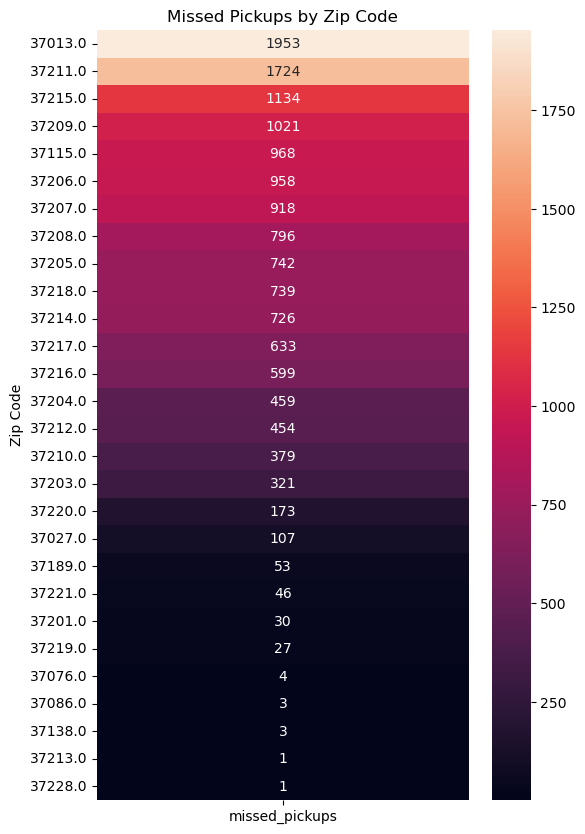

In [23]:
zip_missed_heat = zip_missed.set_index('Zip Code')

plt.figure(figsize=(6,10))
sns.heatmap(zip_missed_heat, annot=True, fmt='g')
plt.title('Missed Pickups by Zip Code')
plt.show()

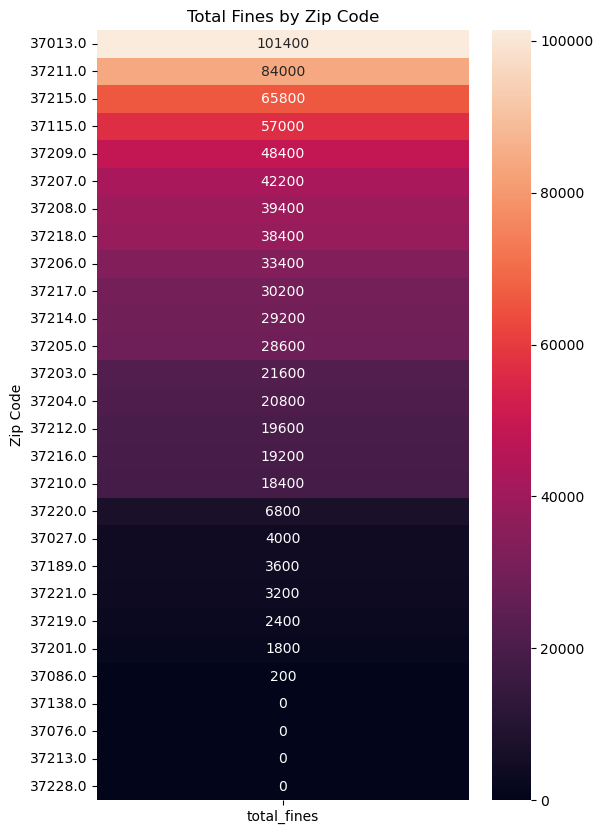

In [24]:
zip_fines_heat = zip_fines.set_index('Zip Code')

plt.figure(figsize=(6,10))
sns.heatmap(zip_fines_heat, annot=True, fmt='g')
plt.title('Total Fines by Zip Code')
plt.show()

In [25]:
hauler_summary = missed.groupby('Trash Hauler Clean').agg(
    missed_pickups=('Request Number', 'count'),
    fined_pickups=('fine_current', lambda s: (s > 0).sum()),
    total_fines=('fine_current', 'sum'),
    unique_addresses=('Incident Address', 'nunique')
).sort_values('total_fines', ascending=False)

hauler_summary

,missed_pickups,fined_pickups,total_fines,unique_addresses
Trash Hauler Clean,,,,
RED RIVER,10715,2551,510200,8190
METRO,2688,589,117800,2107
WASTE IND,1019,219,43800,804


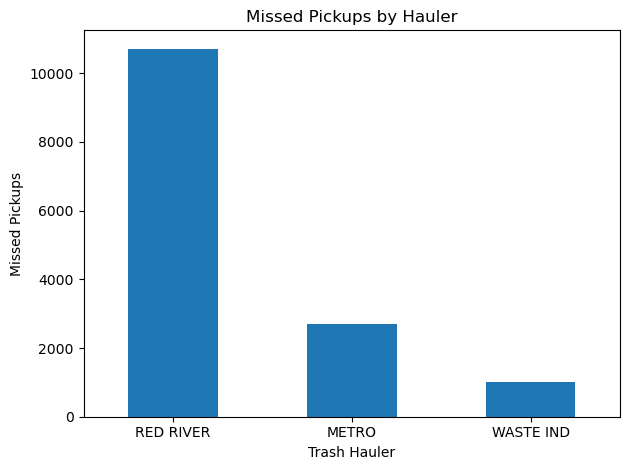

In [26]:
hauler_summary['missed_pickups'].plot(kind='bar')
plt.title('Missed Pickups by Hauler')
plt.xlabel('Trash Hauler')
plt.ylabel('Missed Pickups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Metro vs Contractor Performance

Red River had the highest number of missed pickups and the highest total fines.
Metro had fewer missed pickups and lower fines than Red River.
Waste Industries had the fewest missed pickups and the lowest fines of the three.

In [27]:
hauler_summary[['total_fines']]

,total_fines
Trash Hauler Clean,
RED RIVER,510200
METRO,117800
WASTE IND,43800


## Fines Owed by Each Trash Hauler

- RED RIVER: **$555,000**
- METRO: **$112,400**
- WASTE IND: **$53,400**

In [28]:
route_summary = missed.groupby('Trash Route').agg(
    missed_pickups=('Request Number', 'count'),
    total_fines=('fine_current', 'sum')
).sort_values('missed_pickups', ascending=False)

route_summary.head(15)

,missed_pickups,total_fines
Trash Route,,
4504,305,19200
4404,246,14000
3302,230,13400
3305,215,14600
9303,209,12800
3503,204,9600
3303,198,10400
4304,196,11400
3201,194,11400


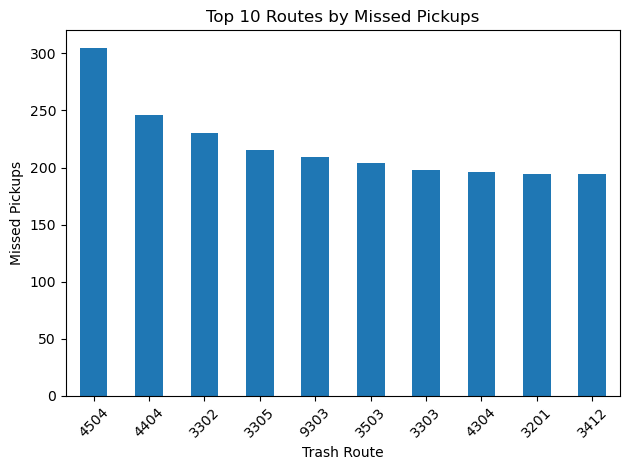

In [29]:
top_routes = route_summary.head(10)

top_routes['missed_pickups'].plot(kind='bar')
plt.title('Top 10 Routes by Missed Pickups')
plt.xlabel('Trash Route')
plt.ylabel('Missed Pickups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
unique_dates = (
    missed[['Incident Address', 'Date Opened']]
    .drop_duplicates()
    .sort_values(['Incident Address', 'Date Opened'])
)
unique_dates.head()

,Incident Address,Date Opened
4477,1 BELLE FORREST AVE C,2018-06-29
4511,10 Belle Forrest Ave,2018-07-02
10929,"100 Bluefield Square, Nashville, TN 37214, Uni...",2019-03-15
2214,100 Braxton Hill Ct,2018-03-07
7727,100 Brook Hollow Rd,2018-12-05


In [31]:
def alt1_count(dates):
    dates = list(dates)
    count = 0
    for i in range(len(dates) - 2):
        if (dates[i + 2] - dates[i]).days <= 180:
            count += 1
    return count

alt1_windows = unique_dates.groupby('Incident Address')['Date Opened'].apply(alt1_count)
alt1_total_fines = alt1_windows.sum() * 1500
alt1_total_fines

np.int64(1414500)

In [32]:
def alt2_count(dates):
    dates = list(dates)
    count = 0
    i = 0
    
    while i <= len(dates) - 3:
        if (dates[i + 2] - dates[i]).days <= 180:
            count += 1
            i += 3
        else:
            i += 1
    return count

alt2_windows = unique_dates.groupby('Incident Address')['Date Opened'].apply(alt2_count)
alt2_total_fines = alt2_windows.sum() * 1500
alt2_total_fines

np.int64(828000)

In [33]:
comparison = pd.DataFrame({
    'Method': ['Current Method', 'Alternative Method 1', 'Alternative Method 2'],
    'Total Fines': [total_fines, alt1_total_fines, alt2_total_fines]
})

comparison

,Method,Total Fines
0,Current Method,720800
1,Alternative Method 1,1414500
2,Alternative Method 2,828000


## Fine Method Comparison

- Current Method: **$720,800**
- Alternative Method 1: **$1,414,500**
- Alternative Method 2: **$828,000**

Alternative Method 1 produces the highest fines because dates can be reused in overlapping 180-day windows.
Alternative Method 2 still increases fines compared with the current method, but it produces less than Alternative Method 1 because dates cannot be reused.